# STAR — EDA et découverte causale (plusieurs algorithmes)

Données : `data/star/STAR.csv`. Sous-ensemble maternelle avec `readk`, `mathk`, covariables encodées en entiers (approximation pour méthodes « continues »).

Méthodes (via [causal-learn](https://github.com/py-why/causal-learn)) :

- **PC** + Fisher Z (CPDAG)
- **FCI** (PAG ; on en déduit un squelette)
- **DirectLiNGAM** (DAG linéaire, non-gaussien)
- **Recherche exacte BIC** (petit graphe, DAG)

*Note :* GES score-based est omis ici (incompatibilité connue `causal-learn` × NumPy 2 sur `local_score_BIC`). Les graphes sont des **estimations algorithmiques**, pas la vérité de terrain du STAR.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.FCMBased.lingam import DirectLiNGAM
from causallearn.search.ScoreBased.ExactSearch import bic_exact_search
try:
    from IPython.display import display
except ImportError:
    def display(x):  # noqa: A001
        if hasattr(x, "to_string"):
            print(x.to_string())
        else:
            print(x)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def _find_repo_root(start: Path) -> Path:
    for d in (start, *start.parents):
        if (d / "pyproject.toml").is_file():
            return d
    raise FileNotFoundError(f"pyproject.toml introuvable en remontant depuis {start}")


def _star_examples_dir(repo: Path) -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parent
    cwd = Path.cwd()
    if (cwd / "star_causal_discovery.ipynb").is_file() or (cwd / "star_causal_discovery.py").is_file():
        return cwd
    fallback = repo / "examples" / "STAR"
    return fallback if fallback.is_dir() else cwd


_start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
_REPO_ROOT = _find_repo_root(_start)
_STAR_DIR = _star_examples_dir(_REPO_ROOT)
_DATA_PATH = _REPO_ROOT / "data" / "star" / "STAR.csv"
_FIG_DIR = _STAR_DIR / "figures"
_RESULTS_DIR = _STAR_DIR / "results"
_FIG_DIR.mkdir(parents=True, exist_ok=True)
_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ALPHA = 0.05
MAX_ROWS = 4000
LINGAM_THRESH = 0.08

## Chargement et encodage

In [2]:
if not _DATA_PATH.is_file():
    raise FileNotFoundError(_DATA_PATH)

raw = pd.read_csv(_DATA_PATH)
cols_needed = ["stark", "readk", "mathk", "gender", "ethnicity", "lunchk", "schoolk"]
df = raw.dropna(subset=["stark", "readk", "mathk"]).copy()
for c in ["stark", "gender", "ethnicity", "lunchk", "schoolk"]:
    df[c] = df[c].astype(str)

if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_STATE).sort_index()

num_cols = ["readk", "mathk"]
cat_cols = ["stark", "gender", "ethnicity", "lunchk", "schoolk"]
encoders: dict[str, LabelEncoder] = {}
X_frame = pd.DataFrame(index=df.index)
for c in num_cols:
    X_frame[c] = pd.to_numeric(df[c], errors="coerce")
for c in cat_cols:
    le = LabelEncoder()
    X_frame[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

names = list(X_frame.columns)
X = np.ascontiguousarray(X_frame.values.astype(np.float64))
display(X_frame.describe().T.round(3))
print("n =", X.shape[0], "p =", X.shape[1], "colonnes :", names)

,count,mean,std,min,25%,50%,75%,max
readk,4000.0,436.662,31.682,315.0,414.0,433.0,453.0,627.0
mathk,4000.0,485.901,48.208,320.0,454.0,484.0,513.0,626.0
stark,4000.0,0.960,0.803,0.0,0.0,1.0,2.0,2.0
gender,4000.0,0.512,0.500,0.0,0.0,1.0,1.0,1.0
ethnicity,4000.0,2.048,1.401,0.0,0.0,3.0,3.0,6.0
lunchk,4000.0,1.032,0.998,0.0,0.0,2.0,2.0,2.0
schoolk,4000.0,1.172,0.881,0.0,1.0,1.0,2.0,3.0


n = 4000 p = 7 colonnes : ['readk', 'mathk', 'stark', 'gender', 'ethnicity', 'lunchk', 'schoolk']


## Distributions et analyses descriptives

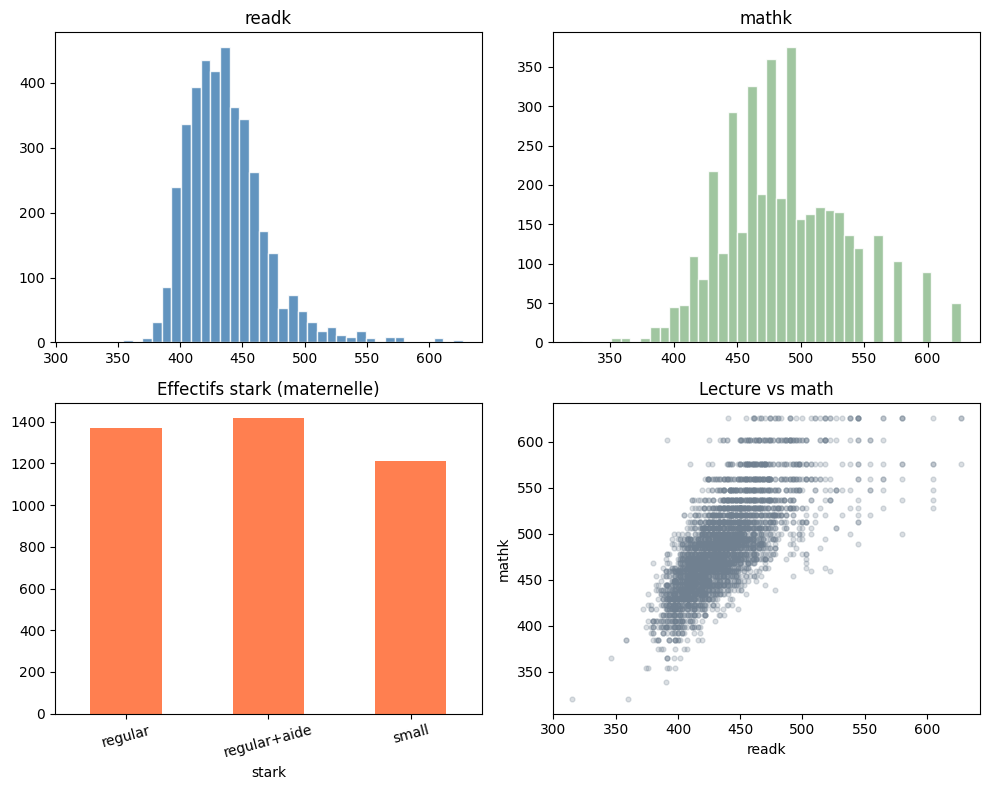

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(X_frame["readk"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0, 0].set_title("readk")
axes[0, 1].hist(X_frame["mathk"], bins=40, color="darkseagreen", edgecolor="white", alpha=0.85)
axes[0, 1].set_title("mathk")
df["stark"].value_counts().reindex(sorted(df["stark"].unique())).plot(kind="bar", ax=axes[1, 0], color="coral", rot=15)
axes[1, 0].set_title("Effectifs stark (maternelle)")
axes[1, 1].scatter(X_frame["readk"], X_frame["mathk"], alpha=0.25, s=12, c="slategray")
axes[1, 1].set_xlabel("readk")
axes[1, 1].set_ylabel("mathk")
axes[1, 1].set_title("Lecture vs math")
plt.tight_layout()
plt.savefig(_FIG_DIR / "star_eda_histograms_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

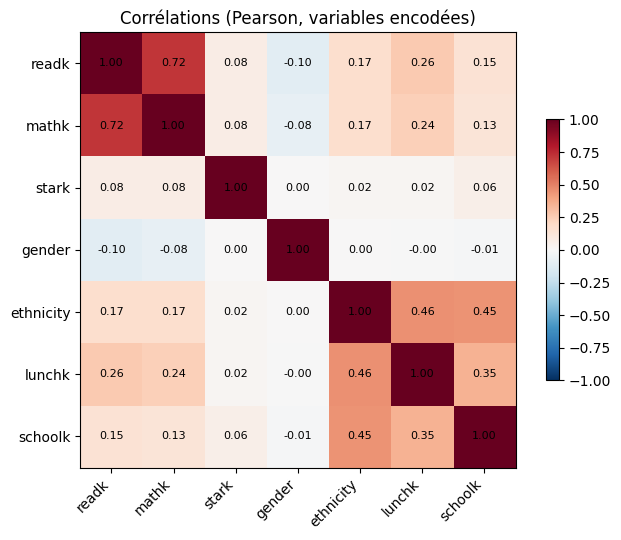

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm = X_frame.corr(numeric_only=True)
im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(cm.columns)))
ax.set_yticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.columns)
for ii in range(cm.shape[0]):
    for jj in range(cm.shape[1]):
        ax.text(jj, ii, f"{cm.values[ii, jj]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.6)
ax.set_title("Corrélations (Pearson, variables encodées)")
plt.tight_layout()
plt.savefig(_FIG_DIR / "star_eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

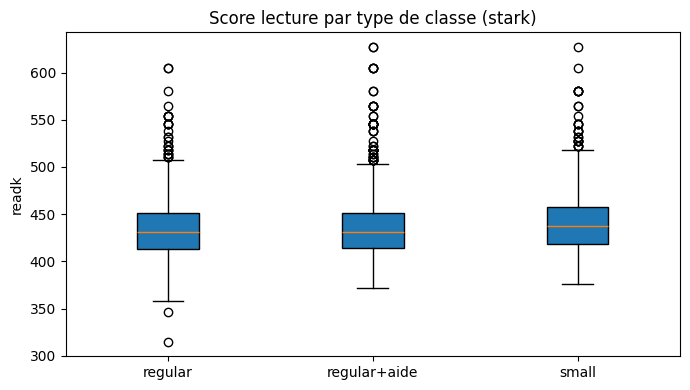

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = sorted(df["stark"].unique())
data_box = [X_frame.loc[df["stark"] == s, "readk"].values for s in order]
ax.boxplot(data_box, tick_labels=order, patch_artist=True)
ax.set_ylabel("readk")
ax.set_title("Score lecture par type de classe (stark)")
plt.tight_layout()
plt.savefig(_FIG_DIR / "star_eda_readk_by_stark.png", dpi=150, bbox_inches="tight")
plt.show()

## Utilitaires graphes (squelette, arcs dirigés)

In [6]:


def skeleton_from_adj(adj: np.ndarray) -> set[frozenset[int]]:
    n = adj.shape[0]
    sk: set[frozenset[int]] = set()
    for i in range(n):
        for j in range(i + 1, n):
            if adj[i, j] != 0 or adj[j, i] != 0:
                sk.add(frozenset({i, j}))
    return sk


def directed_pc_style(graph_mx: np.ndarray) -> set[tuple[int, int]]:
    """Convention causallearn : i → j si graph[j,i]==1 et graph[i,j]==-1."""
    n = graph_mx.shape[0]
    out: set[tuple[int, int]] = set()
    for i in range(n):
        for j in range(n):
            if i != j and graph_mx[j, i] == 1 and graph_mx[i, j] == -1:
                out.add((i, j))
    return out


def undirected_pc_edges(graph_mx: np.ndarray) -> set[frozenset[int]]:
    """Arêtes non orientées du CPDAG : graph[i,j]==graph[j,i]==-1."""
    n = graph_mx.shape[0]
    out: set[frozenset[int]] = set()
    for i in range(n):
        for j in range(i + 1, n):
            if graph_mx[i, j] == -1 and graph_mx[j, i] == -1:
                out.add(frozenset({i, j}))
    return out


def edges_lingam_w(W: np.ndarray, thresh: float) -> set[tuple[int, int]]:
    """W[a,b] coefficient de b dans l'équation de a ⇒ b → a, arc (b,a)."""
    e: set[tuple[int, int]] = set()
    for a in range(W.shape[0]):
        for b in range(W.shape[1]):
            if abs(W[a, b]) > thresh:
                e.add((b, a))
    return e


def edges_bic_dag(adj: np.ndarray, thresh: float = 0.5) -> set[tuple[int, int]]:
    """Matrice DAG exacte : parent j → enfant i si adj[i,j] > thresh."""
    e: set[tuple[int, int]] = set()
    for i in range(adj.shape[0]):
        for j in range(adj.shape[1]):
            if abs(adj[i, j]) > thresh:
                e.add((j, i))
    return e


def edge_label(names_list: list[str], pairs: set[tuple[int, int]]) -> list[str]:
    return sorted(f"{names_list[i]} → {names_list[j]}" for i, j in pairs)


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    u = len(a | b)
    return len(a & b) / u if u else 0.0


def draw_graph(
    title: str,
    n_nodes: int,
    directed: set[tuple[int, int]],
    path: Path,
    undirected_pairs: set[frozenset[int]] | None = None,
) -> None:
    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    G.add_edges_from(directed)
    base = nx.Graph()
    base.add_nodes_from(range(n_nodes))
    base.add_edges_from(directed)
    pos = nx.spring_layout(base, seed=RANDOM_STATE, k=1.1)
    plt.figure(figsize=(7, 6))
    nx.draw_networkx_nodes(G, pos, node_color="lightsteelblue", node_size=900)
    nx.draw_networkx_labels(G, pos, labels={i: names[i] for i in range(n_nodes)}, font_size=9)
    if undirected_pairs:
        Ug = nx.Graph()
        Ug.add_nodes_from(range(n_nodes))
        for p in undirected_pairs:
            a, b = tuple(p)
            Ug.add_edge(a, b)
        nx.draw_networkx_edges(Ug, pos, edge_color="0.55", style="dashed", width=1.8)
    nx.draw_networkx_edges(G, pos, edge_color="0.15", arrows=True, arrowsize=18, width=1.5)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

## Lancement des algorithmes

In [7]:
results: dict[str, object] = {"names": names, "n_samples": int(X.shape[0]), "alpha": ALPHA}

cg = pc(X, alpha=ALPHA, stable=True, uc_rule=True, uc_priority=2, verbose=False)
g_pc = np.asarray(cg.G.graph)
sk_pc = skeleton_from_adj(g_pc)
dir_pc = directed_pc_style(g_pc)
und_pc = undirected_pc_edges(g_pc)
results["PC"] = {
    "skeleton_pairs": [sorted(list(p)) for p in sorted(sk_pc, key=lambda x: (min(x), max(x)))],
    "directed_edges": edge_label(names, dir_pc),
    "undirected_edges": [sorted(list(p)) for p in sorted(und_pc, key=lambda x: (min(x), max(x)))],
}

G_fci, _ = fci(X, independence_test_method="fisherz", alpha=ALPHA, verbose=False)
g_fci = np.asarray(G_fci.graph)
sk_fci = skeleton_from_adj(g_fci)
results["FCI"] = {
    "skeleton_pairs": [sorted(list(p)) for p in sorted(sk_fci, key=lambda x: (min(x), max(x)))],
}

lingam = DirectLiNGAM()
with contextlib.redirect_stdout(io.StringIO()):
    lingam.fit(X)
W = np.asarray(lingam.adjacency_matrix_)
dir_ling = edges_lingam_w(W, LINGAM_THRESH)
sk_ling = skeleton_from_adj((np.abs(W) > LINGAM_THRESH).astype(float))
results["DirectLiNGAM"] = {
    "directed_edges": edge_label(names, dir_ling),
    "skeleton_pairs": [sorted(list(p)) for p in sorted(sk_ling, key=lambda x: (min(x), max(x)))],
    "threshold": LINGAM_THRESH,
}

adj_exact, meta_exact = bic_exact_search(X, search_method="astar", verbose=False)
adj_exact = np.asarray(adj_exact, dtype=float)
dir_exact = edges_bic_dag(adj_exact, thresh=0.5)
sk_exact = skeleton_from_adj(adj_exact)
results["ExactBIC"] = {
    "directed_edges": edge_label(names, dir_exact),
    "skeleton_pairs": [sorted(list(p)) for p in sorted(sk_exact, key=lambda x: (min(x), max(x)))],
    "search_meta": {k: (int(v) if isinstance(v, (int, np.integer)) else v) for k, v in meta_exact.items()},
}

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

X1 --> X2
X2 --> X5
X6 --> X5


## Recoupement (Jaccard sur squelettes et arcs)

In [8]:
skeletons = {"PC": sk_pc, "FCI": sk_fci, "LiNGAM": sk_ling, "ExactBIC": sk_exact}
keys = list(skeletons.keys())
jac_sk = pd.DataFrame(index=keys, columns=keys, dtype=float)
for a in keys:
    for b in keys:
        jac_sk.loc[a, b] = jaccard(skeletons[a], skeletons[b])
display(jac_sk.round(3))

directed_sets = {"PC": dir_pc, "LiNGAM": dir_ling, "ExactBIC": dir_exact}
dkeys = list(directed_sets.keys())
jac_dir = pd.DataFrame(index=dkeys, columns=dkeys, dtype=float)
for a in dkeys:
    for b in dkeys:
        jac_dir.loc[a, b] = jaccard(directed_sets[a], directed_sets[b])
display(jac_dir.round(3))

consensus_dir = set.intersection(*directed_sets.values()) if directed_sets else set()
consensus_sk = set.intersection(*[skeletons[k] for k in ("PC", "FCI", "LiNGAM", "ExactBIC")])
results["consensus"] = {
    "directed_edges_all_three": edge_label(names, consensus_dir),
    "skeleton_pairs_all_four": [sorted(list(p)) for p in sorted(consensus_sk, key=lambda x: (min(x), max(x)))],
    "jaccard_skeleton": jac_sk.round(4).to_dict(),
    "jaccard_directed": jac_dir.round(4).to_dict(),
}

print("Arêtes dirigées présentes dans PC ∩ LiNGAM ∩ ExactBIC :")
for s in results["consensus"]["directed_edges_all_three"]:
    print(" ", s)
print("\nSquelette présent dans les quatre méthodes :")
for s in results["consensus"]["skeleton_pairs_all_four"]:
    print(" ", names[s[0]], "-", names[s[1]])

,PC,FCI,LiNGAM,ExactBIC
PC,1.000,1.000,0.667,0.818
FCI,1.000,1.000,0.667,0.818
LiNGAM,0.667,0.667,1.000,0.538
ExactBIC,0.818,0.818,0.538,1.000


,PC,LiNGAM,ExactBIC
PC,1.000,0.417,0.417
LiNGAM,0.417,1.000,0.333
ExactBIC,0.417,0.333,1.000


Arêtes dirigées présentes dans PC ∩ LiNGAM ∩ ExactBIC :
  ethnicity → lunchk
  gender → readk
  schoolk → lunchk

Squelette présent dans les quatre méthodes :
  readk - mathk
  readk - gender
  mathk - ethnicity
  mathk - lunchk
  ethnicity - lunchk
  ethnicity - schoolk
  lunchk - schoolk


## Visualisations réseau

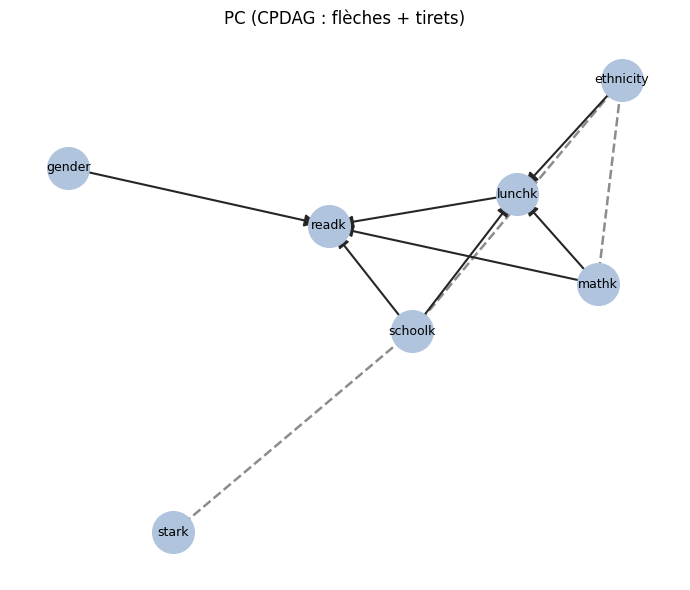

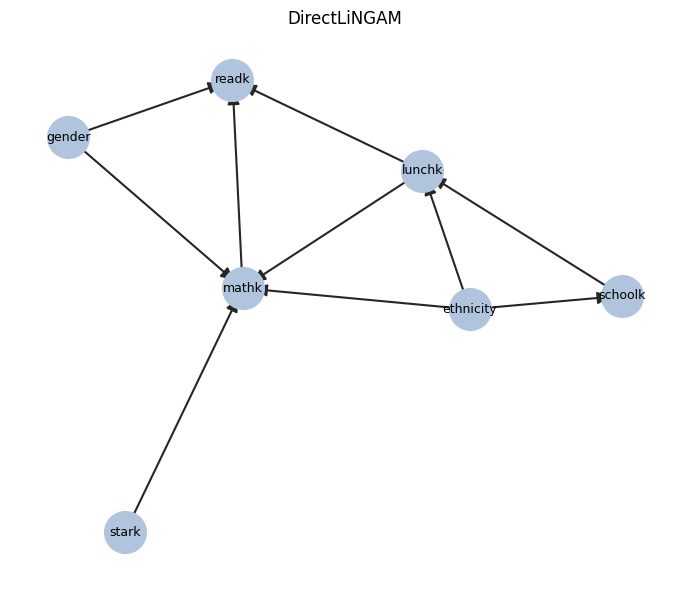

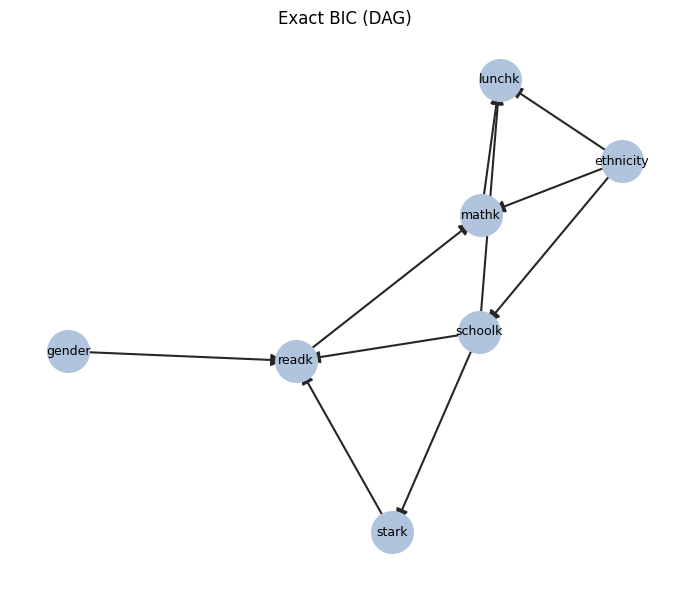

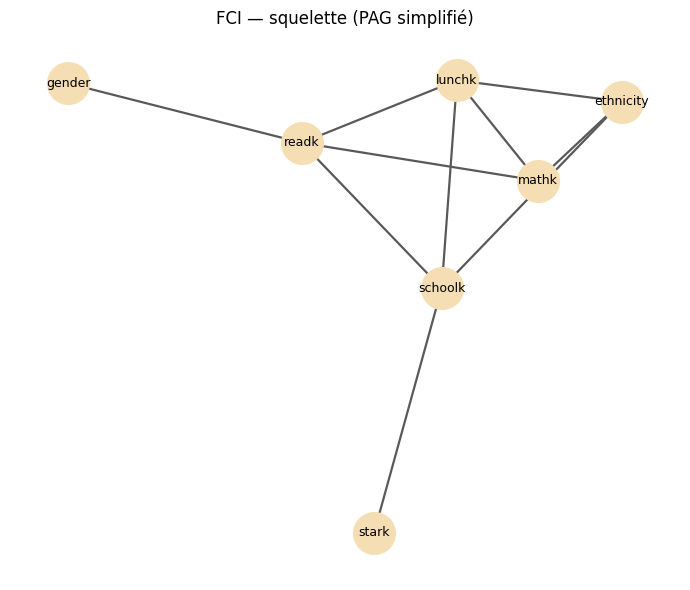

In [9]:
draw_graph("PC (CPDAG : flèches + tirets)", len(names), dir_pc, _FIG_DIR / "cd_graph_pc.png", undirected_pairs=und_pc)
draw_graph("DirectLiNGAM", len(names), dir_ling, _FIG_DIR / "cd_graph_lingam.png", undirected_pairs=None)
draw_graph("Exact BIC (DAG)", len(names), dir_exact, _FIG_DIR / "cd_graph_exact_bic.png", undirected_pairs=None)

Fg = nx.Graph()
Fg.add_nodes_from(range(len(names)))
for p in sk_fci:
    a, b = tuple(p)
    Fg.add_edge(a, b)
pos_f = nx.spring_layout(Fg, seed=RANDOM_STATE, k=1.1)
plt.figure(figsize=(7, 6))
nx.draw_networkx_nodes(Fg, pos_f, node_color="wheat", node_size=900)
nx.draw_networkx_labels(Fg, pos_f, labels={i: names[i] for i in range(len(names))}, font_size=9)
nx.draw_networkx_edges(Fg, pos_f, edge_color="0.35", width=1.6)
plt.title("FCI — squelette (PAG simplifié)")
plt.axis("off")
plt.tight_layout()
plt.savefig(_FIG_DIR / "cd_graph_fci_skeleton.png", dpi=150, bbox_inches="tight")
plt.show()

## Export JSON

In [10]:
def _json_default(obj: object) -> object:
    if isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(type(obj))


out_path = _RESULTS_DIR / "causal_discovery_star.json"
with out_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False, default=_json_default)
print("Écrit :", out_path.relative_to(_REPO_ROOT))

# --- Commentaires après coup ---
# - Encoder les catégories en entiers 0..K-1 traite des niveaux ordinaux comme des réels : PC/FCI (Fisher) et LiNGAM sont alors des approximations.
# - FCI autorise variables latentes ; le squelette peut différer du PC « classique ».
# - LiNGAM suppose un modèle linéaire à bruit non gaussien ; les scores STAR sont grossièrement continus.
# - La recherche exacte BIC suppose DAG et échantillon i.i.d. ; utile comme quatrième avis sur le même tableau encodé.

Écrit : examples/STAR/results/causal_discovery_star.json
